# Lesson 14 — Linear Regression: Predicting a Number

**What this notebook does:** builds our first real *learned* model from scratch. We take past support tickets (how long each was, and how many minutes it took to resolve) and fit the single straight line that best predicts resolution time from ticket length. The line is trained with **gradient descent** — the exact machinery from Lesson 09 — and ends up as just two numbers: a slope and an intercept.

We go step by step:
1. Look at the data.
2. Write the model as a line `minutes = w * x + b`.
3. Score a line with mean squared error.
4. Compute the two slopes (gradients) and run gradient descent.
5. Read the trained numbers, predict for new tickets, and plot the line.
6. Double-check our line against NumPy's exact fitter.

## Step 1 — The data

We have eight tickets we already resolved. For each we know two things: its **length in words** (the input, `x`) and the **minutes it took** (the answer we want to predict, `y`).

Longer tickets tend to take longer — that upward drift is the **signal** linear regression will try to capture.

One practical move: the raw lengths (10…80) are big, and gradient descent gets unstable with large inputs. So we also store each length divided by 10 — the same data measured in *tens of words*, giving small numbers 1…8. (Why big inputs cause trouble, and the general fix, is Lesson 21 — feature scaling. For now, just a friendlier unit.)

In [8]:
# Past tickets we already resolved.
# For each: how long the ticket was (in words) and how many minutes it took.
lengths = [10, 20, 30, 40, 50, 60, 70, 80]         # ticket length in words
minutes = [11, 14, 22, 24, 31, 33, 42, 44]         # minutes it actually took

# Big input numbers make gradient descent jumpy, so we work in "tens of words".
scaled_lengths = []                                # length / 10, an easier unit
for length in lengths:                             # go through each ticket length
    scaled_lengths.append(length / 10)             # 10 words -> 1.0, 80 words -> 8.0

# Compact alternative (same result) - the idiomatic one-line form of the loop above.
# This "list comprehension" is everywhere in real Python. We keep the plain loop as
# the version that runs, but it is worth learning to recognize this shorthand:
#     scaled_lengths = [length / 10 for length in lengths]

# Show the table so we can see the pattern: longer tickets take longer.
print("length(words)  scaled(x)  minutes(y)")
for i in range(len(lengths)):                      # i walks 0..7 over every ticket
    print(f"   {lengths[i]:>4}         {scaled_lengths[i]:>4}       {minutes[i]:>4}")
print()
print("Number of tickets:", len(lengths))

length(words)  scaled(x)  minutes(y)
     10          1.0         11
     20          2.0         14
     30          3.0         22
     40          4.0         24
     50          5.0         31
     60          6.0         33
     70          7.0         42
     80          8.0         44

Number of tickets: 8


## Step 2 — The model is a straight line

A line needs just two numbers:

- **`w`** — the **slope** (its real name is the **weight**): extra minutes for each extra *ten words*.
- **`b`** — the **intercept** (its real name is the **bias**): the baseline minutes when `x = 0`.

So the whole model is `prediction = w * x + b`. "Training" means finding the `w` and `b` that fit the dots best — a linear-regression model *is* just those two learned numbers.

Below we write the line as a function and try a deliberately bad guess (`w=3, b=0`) so we can see how wrong an untrained line is.

In [9]:
# The model is a straight line: prediction = w * x + b
# w is the slope (minutes per ten words), b is the intercept (baseline minutes).
def predict_with(w, b, x):                          # x is the scaled length
    return w * x + b                                # the line's height at x

# Try a deliberately rough first guess and see how far off it is.
guess_w = 3.0                                       # 3 minutes per ten words
guess_b = 0.0                                       # zero baseline
print(f"Guess line: minutes = {guess_w} * x + {guess_b}")
print()
print(" x    predicted   actual   error")
for i in range(len(scaled_lengths)):                # go ticket by ticket
    x = scaled_lengths[i]                            # this ticket's scaled length
    actual = minutes[i]                             # what it really took
    predicted = predict_with(guess_w, guess_b, x)   # what our guess line says
    error = predicted - actual                      # gap (negative = under-predicting)
    print(f"{x:>3}    {predicted:>7.1f}   {actual:>6}   {error:>6.1f}")

Guess line: minutes = 3.0 * x + 0.0

 x    predicted   actual   error
1.0        3.0       11     -8.0
2.0        6.0       14     -8.0
3.0        9.0       22    -13.0
4.0       12.0       24    -12.0
5.0       15.0       31    -16.0
6.0       18.0       33    -15.0
7.0       21.0       42    -21.0
8.0       24.0       44    -20.0


## Step 3 — Measuring how wrong a line is (mean squared error)

To improve a line we first need to *score* it. For each ticket we take `prediction - actual` (the **error**, or gap), **square** it (so over- and under-shooting both count, and big misses hurt much more), and average across all tickets. That average is the **mean squared error (MSE)** — the same loss from Lesson 09.

A line through the middle of the dots gives a small MSE; a tilted or shifted line gives a big one. Our whole goal is to make this number as small as possible.

In [10]:
# Mean squared error: average of the squared gaps. Big gaps hurt a lot more.
def mean_squared_error(w, b):                       # score a whole line
    total_squared_error = 0.0                       # running sum of squared gaps
    for i in range(len(scaled_lengths)):            # every ticket
        x = scaled_lengths[i]                        # scaled length
        actual = minutes[i]                          # true minutes
        predicted = predict_with(w, b, x)            # line's prediction
        error = predicted - actual                   # the gap
        total_squared_error += error * error         # square it, add to the pile
    return total_squared_error / len(scaled_lengths) # average over all tickets

# Loss of our rough guess line: a big number means a bad fit.
guess_loss = mean_squared_error(guess_w, guess_b)
print(f"MSE of the guess line (w={guess_w}, b={guess_b}): {guess_loss:.2f}")

MSE of the guess line (w=3.0, b=0.0): 220.38


## Step 4a — Which way is downhill? The two slopes

The loss depends on two knobs now, `w` and `b`, so the gradient is **two** slopes — one per knob. For MSE with a straight line they come out clean (plain meaning first):

- **Slope for `w`** = average of `(prediction − actual) × x`. If the line over-predicts on the far-right dots (big `x`), this says "tilt `w` down."
- **Slope for `b`** = average of `(prediction − actual)`. If the line sits too high everywhere, this says "lower the whole line."

A **negative** slope means the loss falls as we *increase* that knob — so we push the knob **up**. The next cell prints both slopes at the flat starting point `w=0, b=0`.

### Where those two slopes come from (the chain rule)

These formulas are not magic — they drop straight out of two things you already know: **squaring's slope** (Lesson 09) and a "gear ratio" idea called the **chain rule**. Here is the whole derivation in plain steps.

The loss for one point is the squared gap, and the prediction is our line:

```
squared_error = (prediction − actual)²      where   prediction = w * x + b
```

**Break it into a two-link chain.** Name the gap in the middle `e` (for error):

```
w   ──►   e = (prediction − actual)   ──►   e²  (the loss)
```

To get the slope all the way from `w` to the loss, find the slope of **each link** and multiply them. That "multiply the links" rule is the **chain rule**, and it is just common sense: if turning knob A moves B twice as fast, and B moves C three times as fast, then A moves C six times as fast.

**Link 2 — how does `e²` change as `e` changes?** Pure Lesson 09: the slope of "something squared" is `2 × something`. So:

```
slope of e²  with respect to  e   =   2 * e   =   2 * (prediction − actual)
```

**Link 1 — how does `e` change as `w` changes?** Look at where `w` sits inside `e`:

```
e = (w * x + b) − actual
```

`w` is *multiplied by `x`*, so nudging `w` up a hair moves the prediction by **`x` times the nudge** — the slope of `e` with respect to `w` is just `x`. That `x` is a **gear ratio**: because `w` is multiplied by `x`, a wiggle in `w` gets amplified by `x` before it reaches the error.

**Multiply the two links (chain rule):**

```
slope for w  =  (2 * e) * (x)   =   2 * (prediction − actual) * x
```

For `b`, redo Link 1: inside `e`, the knob `b` is only *added*, so nudging it moves the prediction one-for-one — gear ratio `1`, not `x`:

```
slope for b  =  (2 * e) * (1)   =   2 * (prediction − actual)
```

**Then average over all points.** The real loss is the *average* of the per-point losses, and the slope of an average is the average of the slopes. So across the whole dataset:

```
slope for w  =  average of   2 * (prediction − actual) * x
slope for b  =  average of   2 * (prediction − actual)
```

That is exactly what the two bullets above say. The plain-English version just drops the constant `2` — it only scales the step size (which the learning rate already controls) and never changes the *direction*. The code in the next cell keeps the `2` explicitly, as `(2 / n) * ...`.

**Sanity check with real numbers (the Lesson 09 nudge test).** One point: `x = 2`, `actual = 14`, current `w = 3`, `b = 0`, so `prediction = 6` and `e = 6 − 14 = −8`. The formula says the per-point slope for `w` is `2 * (−8) * 2 = −32`. Now nudge `w` and watch the loss instead:

```
w = 2.999  ->  prediction 5.998  ->  e = −8.002  ->  e² = 64.032
w = 3.001  ->  prediction 6.002  ->  e = −7.998  ->  e² = 63.968
slope ≈ (63.968 − 64.032) / (3.001 − 2.999) = −0.064 / 0.002 = −32   ✓
```

The formula and the nudge agree exactly — the formula is just the shortcut that saves you from nudging every knob by hand (essential once a model has millions of them).

**The plain meaning to keep:**
- **Why `× x` for `w`:** a point far out (big `x`) swings its prediction a lot when you turn `w`, so it gets a bigger vote in how `w` should move — errors are weighted by how much leverage each point has on `w`.
- **Why no `× x` for `b`:** turning `b` shifts every prediction by the same amount, so no point has more leverage than another; you just average the plain errors.
- **The sign steers:** if predictions run too high (`prediction − actual` positive), the slope is positive, so `w = w − lr * slope` *lowers* the knob; too low, and it raises it.

In [16]:
# The loss has two knobs now (w and b), so gradient descent needs two slopes.
# Slope for w = average of (prediction - actual) * x  -> how loss reacts to tilting
# Slope for b = average of (prediction - actual)       -> how loss reacts to raising
def compute_gradients(w, b):
    w_slope_total = 0.0                            # running sum for the w-slope
    b_slope_total = 0.0                            # running sum for the b-slope
    n = len(scaled_lengths)                        # number of tickets
    for i in range(n):                             # every ticket contributes
        x = scaled_lengths[i]                       # scaled length
        actual = minutes[i]                         # true minutes
        predicted = predict_with(w, b, x)           # current prediction
        error = predicted - actual                  # the gap
        w_slope_total += error * x                  # weight the gap by x for w
        b_slope_total += error                      # plain gap for b

    # First average each running sum over all the tickets...
    w_slope_average = w_slope_total / n
    b_slope_average = b_slope_total / n
    # ...then multiply by 2 (the factor that comes from squaring, Lesson 09).
    w_slope = 2 * w_slope_average
    b_slope = 2 * b_slope_average
    return w_slope, b_slope

# Look at the slopes at our starting point w=0, b=0 (a flat line on the floor).
start_w_slope, start_b_slope = compute_gradients(0.0, 0.0)
print("At w=0, b=0:")
print(f"  slope for w: {start_w_slope:.2f}  (negative -> push w UP)")
print(f"  slope for b: {start_b_slope:.2f}  (negative -> push b UP)")

At w=0, b=0:
  slope for w: -300.00  (negative -> push w UP)
  slope for b: -55.25  (negative -> push b UP)


## Step 4b — The training loop

Now we just repeat the same nudge many times:

```
w  <-  w  -  learning_rate * (slope for w)
b  <-  b  -  learning_rate * (slope for b)
```

Each pass: measure both slopes, take a small step against each (downhill), repeat. The `learning_rate` (0.01) controls step size — small and safe. After a couple thousand steps the line settles onto the best fit and the loss stops falling. Watch the printed loss shrink.

In [12]:
# Train: start flat, then repeatedly step both knobs a little downhill.
w = 0.0                                            # start the slope at 0
b = 0.0                                            # start the intercept at 0
learning_rate = 0.01                               # step size (small = safe)
iterations = 2000                                  # how many nudges to take

for step in range(iterations):                     # one nudge per loop
    w_slope, b_slope = compute_gradients(w, b)  
    print(w_slope, b_slope)   # which way is downhill?
    w = w - learning_rate * w_slope                # step w against its slope
    b = b - learning_rate * b_slope                # step b against its slope
    if step % 200 == 0:                            # print progress now and then
        current_loss = mean_squared_error(w, b)    # how good is the line right now
        print(f"step {step:>4}:  w={w:6.3f}  b={b:6.3f}  loss={current_loss:8.3f}")

# The final trained line.
print()
print(f"Trained line: minutes = {w:.3f} * (length/10) + {b:.3f}")
print(f"Final loss: {mean_squared_error(w, b):.3f}")

-300.0 -55.25
step    0:  w= 3.000  b= 0.552  loss= 205.072
-142.0275 -27.145000000000003
-67.150425 -13.819625
-31.659941999999983 -7.499694249999997
-14.838399097499998 -4.5003055849999996
-6.865788055124991 -3.074843554524999
-3.087500227104031 -2.3954257584732552
-1.2972867930183778 -2.069642222864427
-0.4494027285211599 -1.911493567035476
-0.04817291594219597 -1.8328174501278656
0.14134884169984296 -1.791825538690508
0.23052523091507915 -1.7687104236696833
0.27214130127862113 -1.7540834859786525
0.29121675136461 -1.7434945333741547
0.29961071617234847 -1.7348341503294833
0.302944324454125 -1.7271024317784027
0.303881937842565 -1.7198253723437062
0.30368643305381227 -1.7127782393026605
0.30295639373358174 -1.705854453491455
0.3019755337436667 -1.699003439857651
0.3008783211216093 -1.6922011690974235
0.29972848256837636 -1.6854361946164174
0.29855621397395815 -1.6787030341552458
0.2973758179212078 -1.6719990327297984
0.29619406372707235 -1.6653228756881107
0.29501415003824416 -1.658

## Step 5 — Reading the trained numbers

The training loop leaves us with a final `w` and `b` — for this data, roughly `w ≈ 4.9` and `b ≈ 5.6`. Read them in plain English:

- **`b ≈ 5.6`** — a baseline of about 5.6 minutes even for a very short ticket.
- **`w ≈ 4.9`** — about 4.9 extra minutes for every ten words of length.

That is the entire model. To predict a new ticket we scale its length the same way and read the minutes off the line. Note the last example (100 words) is *longer than anything we trained on* — the model will still answer, but predicting outside the training range (**extrapolation**) is a guess to treat with care.

In [13]:
# Use the trained model on brand-new tickets it has never seen.
def predict_minutes(length_words):                 # takes a raw length in words
    x = length_words / 10                           # scale it the same way we trained
    return predict_with(w, b, x)                    # read the minutes off the line

for new_length in [15, 55, 100]:                    # three fresh tickets
    predicted = predict_minutes(new_length)         # ask the model
    print(f"A {new_length}-word ticket -> about {predicted:.1f} minutes to resolve")

A 15-word ticket -> about 12.9 minutes to resolve
A 55-word ticket -> about 32.5 minutes to resolve
A 100-word ticket -> about 54.5 minutes to resolve


## Step 6 — See the line of best fit

A picture makes it obvious. We scatter the real tickets as dots and draw the trained line through them. A good fit runs right down the middle of the cloud of dots. The image is also saved as a PNG under `plots/`.

Saved: plots/lesson-14-line-of-best-fit.png


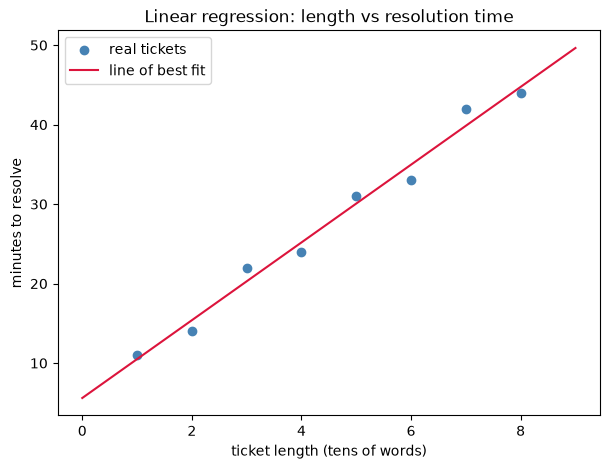

In [17]:
import matplotlib.pyplot as plt                    # the plotting library
import os                                          # to make a folder for the image

# Scatter the real tickets as dots.
plt.figure(figsize=(7, 5))                         # a fresh canvas
plt.scatter(scaled_lengths, minutes, color="steelblue", label="real tickets")

# Draw the trained line across the whole range.
line_x = [0, 9]                                    # two x-values span the plot
line_y = []                                        # matching y-values on the line
for x in line_x:                                   # for each end of the line
    line_y.append(predict_with(w, b, x))           # height of the line at that x
plt.plot(line_x, line_y, color="crimson", label="line of best fit")

plt.xlabel("ticket length (tens of words)")        # label the axes
plt.ylabel("minutes to resolve")
plt.title("Linear regression: length vs resolution time")
plt.legend()

os.makedirs("plots", exist_ok=True)                # make a plots/ folder if missing
plt.savefig("plots/lesson-14-line-of-best-fit.png", dpi=120)  # save the picture
print("Saved: plots/lesson-14-line-of-best-fit.png")
plt.show()                                         # display it in the notebook

## Step 7 — A sanity check against NumPy

For a straight line there is actually an exact formula for the best fit — no stepping required. `np.polyfit(x, y, 1)` uses it and hands back `[slope, intercept]`. If our gradient-descent line lands very close to NumPy's exact line, that is strong evidence our from-scratch training worked.

> **Verify-as-you-go:** `np.polyfit(x, y, deg)` returns coefficients **highest power first**, so for `deg=1` that is `[slope, intercept]`. Confirm against the current NumPy docs if in doubt.

In [15]:
import numpy as np                                 # NumPy has a one-call line fitter

# np.polyfit(x, y, 1) fits a degree-1 polynomial (a straight line) and
# returns [slope, intercept] using an exact formula (no gradient descent).
coeffs = np.polyfit(scaled_lengths, minutes, 1)    # fit the best line directly
numpy_w = coeffs[0]                                # the slope it found
numpy_b = coeffs[1]                                # the intercept it found

print(f"Our gradient-descent line: w={w:.3f}, b={b:.3f}")
print(f"NumPy's exact line:        w={numpy_w:.3f}, b={numpy_b:.3f}")
print()
print("They should be very close - two roads to the same best-fit line.")

Our gradient-descent line: w=4.893, b=5.606
NumPy's exact line:        w=4.893, b=5.607

They should be very close - two roads to the same best-fit line.


## Recap — what we just built

- A **linear-regression** model is nothing but **two learned numbers**: a slope `w` (minutes per ten words) and an intercept `b` (baseline minutes).
- We scored a line with **mean squared error** (average of squared gaps) — the same loss from Lesson 09.
- **Gradient descent** found the best `w` and `b` by nudging both a little, over and over, in the downhill direction.
- The trained line was roughly `minutes = 4.9 * (length/10) + 5.6`, and `np.polyfit` agreed — a good independent check.
- No human wrote the rule '5 minutes per ten words'; the model **learned** it from the data. That is the whole point of machine learning.